2) Для следующих данных:
79 80 80 80 74 80 80 79 64 78 73 78 74 45 81 48 80 82 82 70
- (a.) Получите квартили.
- (b.) Определите межквартильный размах.
- (c.) Найдите минимум, Q25, медиану, Q75 и максимум
- (d.) Определите потенциальные выбросы, если таковые имеются.
- (e.) Постройте ящик с усами.

In [1]:
import numpy as np

data = [79, 80, 80, 80, 74, 80, 80, 79, 64, 78, 73, 78, 74, 45, 81, 48, 80, 82, 82, 70]
q25, q50, q75 = np.percentile(data, [25, 50, 75])

print(f"Q1 (25-й персентиль): {q25}")
print(f"Q2 (Медиана, 50-й персентиль): {q50}")
print(f"Q3 (75-й персентиль): {q75}")

Q1 (25-й персентиль): 73.75
Q2 (Медиана, 50-й персентиль): 79.0
Q3 (75-й персентиль): 80.0


In [2]:
IQR = q75 - q25
print(f"Межквартильный размах (IQR): {IQR}")

Межквартильный размах (IQR): 6.25


In [3]:
min_val = np.min(data)
max_val = np.max(data)

print(f"Минимум: {min_val}")
print(f"Q1 (25-й персентиль): {q25}")
print(f"Медиана (Q2): {q50}")
print(f"Q3 (75-й персентиль): {q75}")
print(f"Максимум: {max_val}")

Минимум: 45
Q1 (25-й персентиль): 73.75
Медиана (Q2): 79.0
Q3 (75-й персентиль): 80.0
Максимум: 82


In [5]:
lower_bound = q25 - 1.5 * IQR
upper_bound = q75 + 1.5 * IQR

outliers = [x for x in data if x < lower_bound or x > upper_bound]
print(f"Потенциальные выбросы: {outliers}")

Потенциальные выбросы: [64, 45, 48]


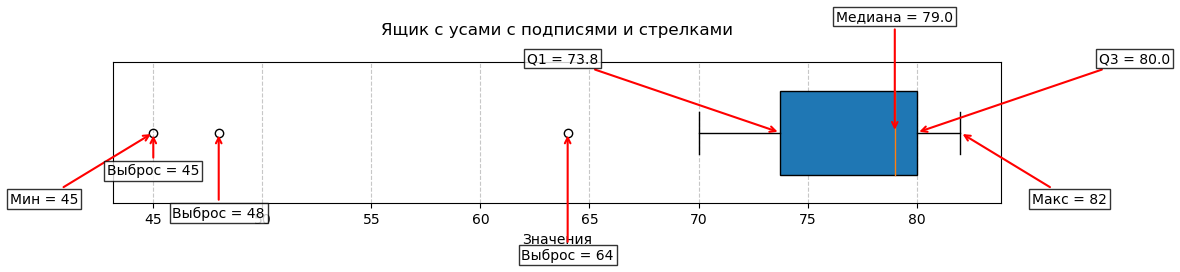

In [8]:
import matplotlib.pyplot as plt

# Строим ящик с усами
plt.figure(figsize=(12, 4))
box = plt.boxplot(data, vert=False, patch_artist=True, widths=0.6)
plt.title("Ящик с усами с подписями и стрелками", pad=20)
plt.xlabel("Значения")
plt.yticks([]) 

arrowprops = dict(arrowstyle="->", color="red", lw=1.5)
textprops = dict(bbox=dict(fc="white", alpha=0.8, pad=2), fontsize=10)

plt.annotate(f"Q1 = {q25:.1f}", xy=(q25, 1), xytext=(q25 - 10, 1.5),
             arrowprops=arrowprops, **textprops, ha='center')
plt.annotate(f"Медиана = {q50:.1f}", xy=(q50, 1), xytext=(q50, 1.8),
             arrowprops=arrowprops, **textprops, ha='center')
plt.annotate(f"Q3 = {q75:.1f}", xy=(q75, 1), xytext=(q75 + 10, 1.5),
             arrowprops=arrowprops, **textprops, ha='center')

plt.annotate(f"Мин = {min_val}", xy=(min_val, 1), xytext=(min_val - 5, 0.5),
             arrowprops=arrowprops, **textprops, ha='center')
plt.annotate(f"Макс = {max_val}", xy=(max_val, 1), xytext=(max_val + 5, 0.5),
             arrowprops=arrowprops, **textprops, ha='center')

if outliers:
    for i, outlier in enumerate(sorted(set(outliers))):
        y_offset = 0.3 * (i + 1)  
        plt.annotate(f"Выброс = {outlier}", xy=(outlier, 1), 
                     xytext=(outlier, 1 - y_offset),
                     arrowprops=arrowprops, **textprops, ha='center')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()